<a href="https://colab.research.google.com/github/juliafoliveira-tech/Bioestat-stica/blob/main/Tarefa13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Julia Feitosa NºUSP: 16228410
* Raissa Pereira Lima da Silva NºUSP: 14605077
* Stéfani Machado NºUSP: 15291452

Fonte: UCI Machine Learning Repository (Disponível em: https://archive.ics.uci.edu/dataset/53/iris

Instituição Responsável: Coletado por Edgar Anderson e popularizado por Ronald Fisher (1936).

Data de Acesso: Outubro de 2026.

Unidade Experimental: Uma planta individual (uma flor coletada).

Significado de cada linha: Cada linha representa uma amostra individual de flor pertencente a uma das três espécies de *Iris* (*Iris setosa, Iris versicolor* ou *Iris virginica*).

Variáveis e Unidades: Comprimento e largura da sépala e da pétala, expressos em centímetros (cm), sendo variáveis quantitativas contínuas.

Critérios de seleção e dados ausentes: O dataset completo possui 150 instâncias (50 por espécie) sem valores ausentes (*missing values*). Para a nossa análise comparativa, podemos isolar as espécies *Iris versicolor e Iris virginica*.

In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

# metadata
print(iris.metadata)

# variable information
print(iris.variables)


{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

Pergunta Biológica Investigável:
"O comprimento das pétalas da espécie *Iris virginica* pode ser modelado por uma distribuição Normal, e a razão entre as variâncias do comprimento das pétalas entre *Iris versicolor* e *Iris virginica* difere significativamente do valor esperado sob a hipótese de igualdade?"

## 1. Distribuição Normal

### 1.1. Fórmula da Função Densidade de Probabilidade (PDF)

A função densidade de probabilidade de uma variável aleatória contínua $X$ com distribuição Normal é definida por:

$$f(x; \mu, \sigma^2) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left( -\frac{1}{2} \left(\frac{x - \mu}{\sigma}\right)^2 \right), \quad x \in \mathbb{R}$$

**Definição dos símbolos:**
* $x$: Valor assumido pela variável de interesse (neste contexto, o comprimento da pétala da flor em cm).
* $\mu$: Média populacional, representando o ponto central e o eixo de simetria bilateral da curva.
* $\sigma$: Desvio padrão populacional (onde $\sigma > 0$), indicando o grau de dispersão dos dados ao redor da média.
* $\pi$ e $\exp$: Constante de Pi (~3.14159) e a função exponencial de base e (~2.71828).

*Fonte Consultada:* Bussab, W. O., & Morettin, P. A. (2017). *Estatística Básica*. 9ª edição, Saraiva.

---

### 1.2. Representação Biológica na Análise

A distribuição Normal é proposta aqui como um modelo teórico direto para representar a variabilidade do **comprimento das pétalas da espécie *Iris virginica***. Biologicamente, características morfológicas são comumente influenciadas por múltiplos fatores genéticos e ambientais agindo de forma aditiva. Pelo Teorema Central do Limite em escala micro-evolutiva, essa soma de efeitos independentes resulta em uma distribuição simétrica de frequências em torno de um comprimento médio característico da espécie.

*   **Diferenciação Importante:** O comprimento medido de uma pétala individual de *Iris virginica* é uma **medida física de um organismo**. Ela pode de fato seguir uma distribuição Normal na natureza. Isso difere de uma **estatística calculada a partir de uma amostra**, que sumariza as propriedades de um grupo coletado (como a variância amostral ou a média amostral) e obedece a outras distribuições teóricas.

---

### 1.3. Parâmetros, Valores Admissíveis e Efeitos

*   **Média ($\mu \in \mathbb{R}$):** Define a posição horizontal da curva. Alterações em $\mu$ deslocam a curva para a esquerda ou direita (efeito de translação) sem alterar seu formato ou dispersão.
*   **Desvio Padrão ($\sigma > 0$):** Controla o achatamento. Valores menores de $\sigma$ estreitam a distribuição (maior homogeneidade), enquanto valores maiores a achatam e espalham (maior heterogeneidade).

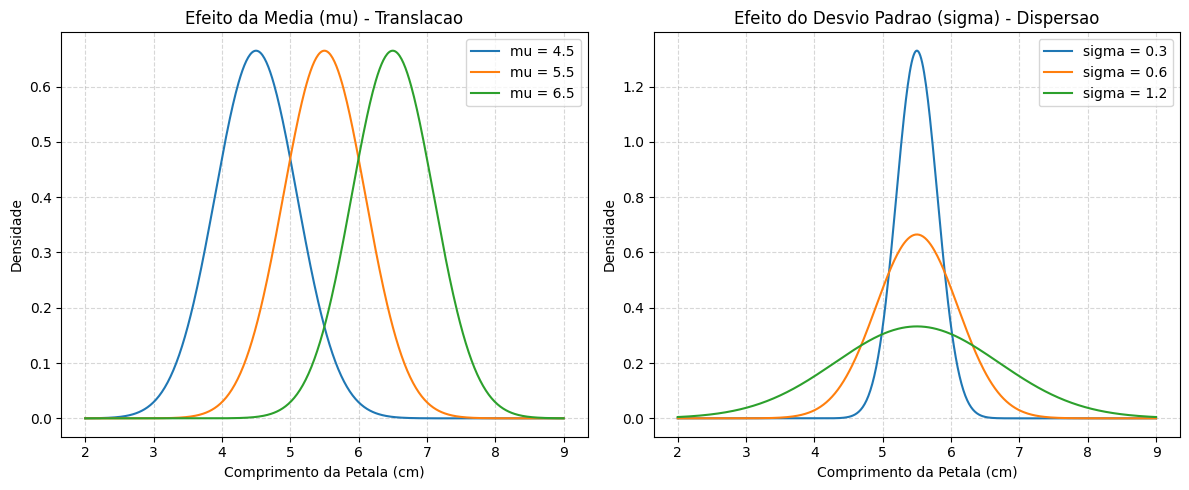

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x_vals = np.linspace(2, 9, 500)
plt.figure(figsize=(12, 5))

# Variando mu
plt.subplot(1, 2, 1)
for mu_val in [4.5, 5.5, 6.5]:
    plt.plot(x_vals, stats.norm.pdf(x_vals, loc=mu_val, scale=0.6), label=f'mu = {mu_val}')
plt.title('Efeito da Media (mu) - Translacao')
plt.xlabel('Comprimento da Petala (cm)')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Variando sigma
plt.subplot(1, 2, 2)
for sig_val in [0.3, 0.6, 1.2]:
    plt.plot(x_vals, stats.norm.pdf(x_vals, loc=5.5, scale=sig_val), label=f'sigma = {sig_val}')
plt.title('Efeito do Desvio Padrao (sigma) - Dispersao')
plt.xlabel('Comprimento da Petala (cm)')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 2. Distribuição t de Student

### 2.1. Fórmula da Função Densidade de Probabilidade (PDF)

A PDF de uma variável $T$ seguindo a distribuição t de Student com $\nu$ graus de liberdade é expressa por:

$$f(t; \nu) = \frac{\Gamma\left(\frac{\nu + 1}{2}
\right)}{\sqrt{\nu\pi} \, \Gamma\left(\frac{\nu}{2}\right)} \left(1 + \frac{t^2}{\nu}\right)^{-\frac{\nu + 1}{2}}, \quad t \in \mathbb{R}$$

Onde $\Gamma(z)$ é a função Gamma dada por $\Gamma(z) = \int_{0}^{\infty} x^{z-1} e^{-x} dx$.

*Fonte Consultada:* Casella, G., & Berger, R. L. (2021). *Inferência Estatística*. Cengage Learning.

---

### 2.2. Representação Biológica na Análise

Ao testar se a média do comprimento das pétalas de *Iris virginica* é estatisticamente igual a um valor fixo especificado, a verdadeira variabilidade populacional ($\sigma^2$) é desconhecida e estimada a partir do desvio padrão amostral ($S$).

*   **Diferenciação Importante:** Nenhuma flor possui "$t$ de comprimento". A distribuição t modela uma **estatística calculada** a partir de nossa amostra:
    $$T = \frac{\bar{X} - \mu_0}{S / \sqrt{n}}$$
    A estatística $T$ incorpora a flutuação amostral de duas variáveis estimadas ao mesmo tempo: a média amostral $\bar{X}$ (no numerador) e o desvio padrão amostral $S$ (no denominador).

---

### 2.3. Parâmetros, Valores Admissíveis e Efeitos

*   **Graus de Liberdade ($\nu > 0$):** Controla o peso das caudas.
    *   Para valores pequenos de $\nu$, a curva possui caudas mais largas que a Normal (refletindo a incerteza de estimar $\sigma$ com poucos dados).
    *   À medida que $\nu \to \infty$, a distribuição t de Student converge para a distribuição Normal Padrão $\mathcal{N}(0, 1)$.

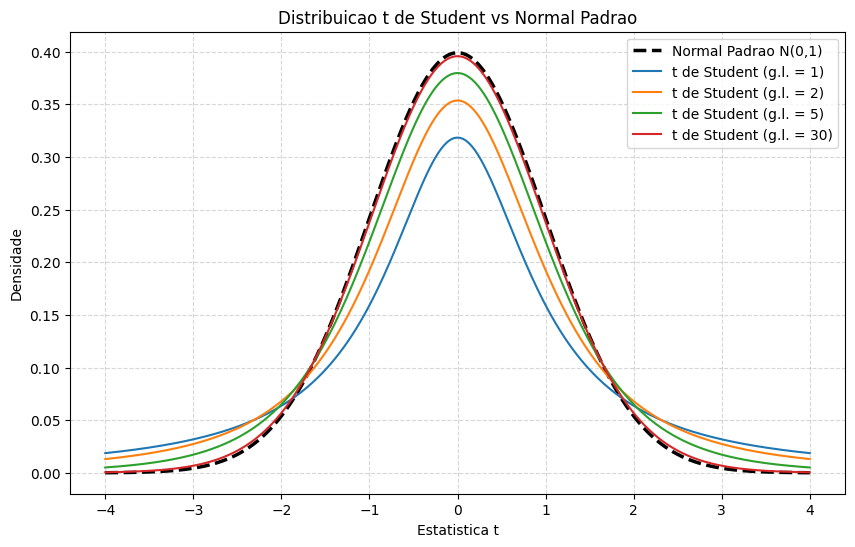

In [18]:
t_vals = np.linspace(-4, 4, 500)
plt.figure(figsize=(10, 6))

# Referencia Normal Padrao
plt.plot(t_vals, stats.norm.pdf(t_vals), 'k--', label='Normal Padrao N(0,1)', linewidth=2.5)

# Variando graus de liberdade
for df_val in [1, 2, 5, 30]:
    plt.plot(t_vals, stats.t.pdf(t_vals, df=df_val), label=f't de Student (g.l. = {df_val})')

plt.title('Distribuicao t de Student vs Normal Padrao')
plt.xlabel('Estatistica t')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 3. Distribuição Qui-quadrado ($\chi^2$)

### 3.1. Fórmula da Função Densidade de Probabilidade (PDF)

A função densidade de uma variável $Y$ com distribuição Qui-quadrado com $\nu$ graus de liberdade é:

$$f(y; \nu) = \frac{1}{2^{\frac{\nu}{2}} \Gamma\left(\frac{\nu}{2}\right)} y^{\frac{\nu}{2} - 1} e^{-\frac{y}{2}}, \quad y \ge 0$$

*Fonte Consultada:* Bussab, W. O., & Morettin, P. A. (2017). *Estatística Básica*.

---

### 3.2. Representação Biológica na Análise

Esta distribuição descreve a variabilidade estocástica associada à estimativa da variabilidade biológica populacional.

*   **Diferenciação Importante:** Não medimos flores com valores Qui-quadrado. Ela é uma **estatística amostral**. Se o comprimento de pétala seguir uma distribuição Normal, a soma dos quadrados das variações individuais em torno da média da amostra segue uma distribuição Qui-quadrado de forma que:
    $$\chi^2 = \frac{(n-1)S^2}{\sigma^2}$$
    modela o comportamento do desvio da variância amostral ($S^2$) em relação à verdadeira variância populacional ($\sigma^2$).

---

### 3.3. Parâmetros, Valores Admissíveis e Efeitos

*   **Graus de Liberdade ($\nu > 0$):** Controla tanto o centro quanto a assimetria da curva.
    *   Como resulta de somas de quadrados, ela é estritamente positiva ($y \ge 0$).
    *   Para $\nu$ pequeno, há uma forte assimetria positiva à direita. À medida que $\nu$ cresce, a distribuição se desloca para a direita (com média $\nu$ e variância $2\nu$) e torna-se gradativamente simétrica devido ao Teorema Central do Limite.

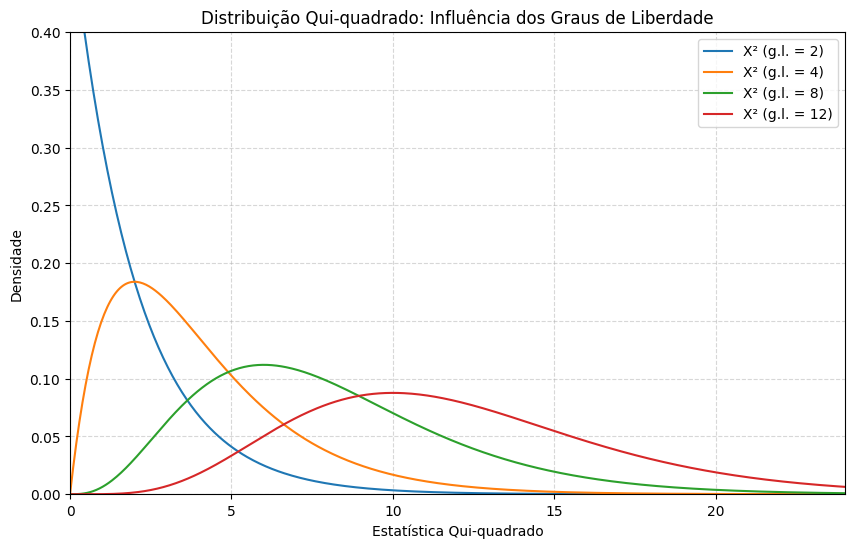

In [15]:
y_vals = np.linspace(0, 24, 500)
plt.figure(figsize=(10, 6))

for df_val in [2, 4, 8, 12]:
    plt.plot(y_vals, stats.chi2.pdf(y_vals, df=df_val), label=f'X² (g.l. = {df_val})')

plt.title('Distribuição Qui-quadrado: Influência dos Graus de Liberdade')
plt.xlabel('Estatística Qui-quadrado')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, 24)
plt.ylim(0, 0.4)
plt.show()

## 4. Distribuição F de Fisher-Snedecor

### 4.1. Fórmula da Função Densidade de Probabilidade (PDF)

A PDF para a variável $W$ de uma distribuição F com $\nu_1$ e $\nu_2$ graus de liberdade é:

$$f(w; \nu_1, \nu_2) = \frac{\Gamma\left(\frac{\nu_1 + \nu_2}{2}\right)}{\Gamma\left(\frac{\nu_1}{2}
\right)\Gamma\left(\frac{\nu_2}{2}\right)} \left(\frac{\nu_1}{\nu_2}\right)^{\frac{\nu_1}{2}} \frac{w^{\frac{\nu_1}{2}-1}}{\left(1 + \frac{\nu_1}{\nu_2}w\right)^{\frac{\nu_1+\nu_2}{2}}}, \quad w \ge 0$$

*Fonte Consultada:* Casella, G., & Berger, R. L. (2021). *Inferência Estatística*.

---

### 4.2. Representação Biológica na Análise

Nesta análise biológica, ela é essencial para testar se a razão entre as variâncias do comprimento de pétala entre *Iris versicolor* e *Iris virginica* difere significativamente de 1.

*   **Diferenciação Importante:** Ela modela estritamente a **estatística calculada de comparação de variâncias** e não propriedades físicas individuais da flor. Definimos:
    $$F = \frac{S^2_{\text{versicolor}}}{S^2_{\text{virginica}}}$$
    Se a homogeneidade de variâncias for preservada populacionalmente ($H_0: \sigma^2_1 = \sigma^2_2$), esta estatística amostral deve seguir teoricamente uma distribuição $F$ com $\nu_1=n_1-1$ e $\nu_2=n_2-1$.

---

### 4.3. Parâmetros, Valores Admissíveis e Efeitos

*   **Graus de Liberdade do Numerador ($\nu_1 > 0$) e Denominador ($\nu_2 > 0$):**
    *   $\nu_1$ altera o pico e o comportamento da densidade perto de 0.
    *   $\nu_2$ está associado ao comportamento do numerador do denominador, alterando fortemente a taxa de decrescimento e a espessura da cauda direita.

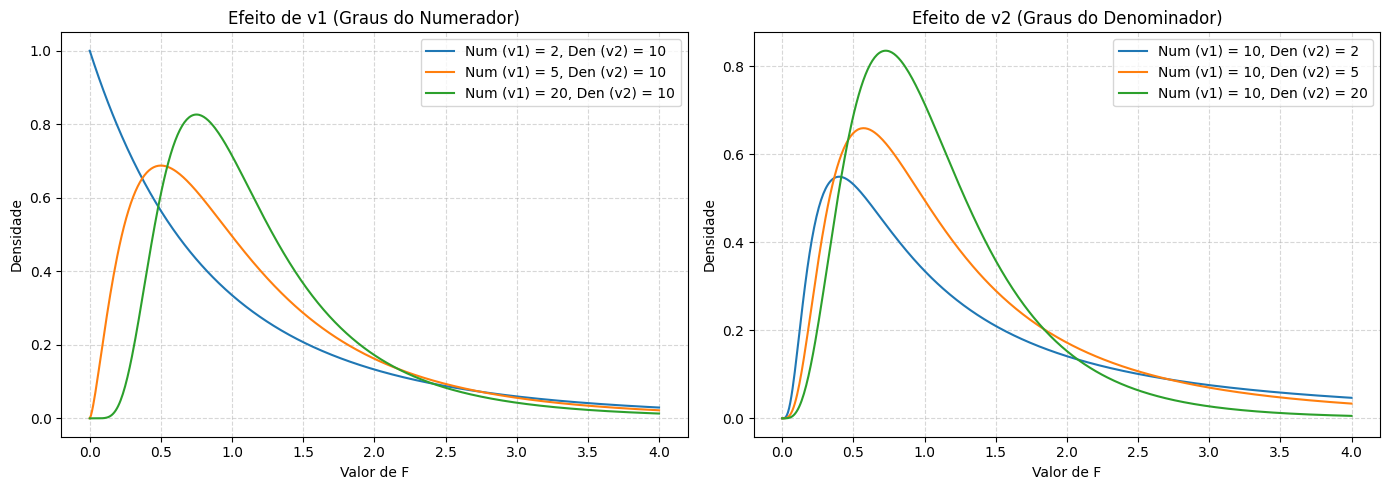

In [19]:
w_vals = np.linspace(0, 4, 500)
plt.figure(figsize=(14, 5))

# 1. Variando dfn (numerador)
plt.subplot(1, 2, 1)
for dfn_val in [2, 5, 20]:
    plt.plot(w_vals, stats.f.pdf(w_vals, dfn=dfn_val, dfd=10), label=f'Num (v1) = {dfn_val}, Den (v2) = 10')
plt.title('Efeito de v1 (Graus do Numerador)')
plt.xlabel('Valor de F')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 2. Variando dfd (denominador)
plt.subplot(1, 2, 2)
for dfd_val in [2, 5, 20]:
    plt.plot(w_vals, stats.f.pdf(w_vals, dfn=10, dfd=dfd_val), label=f'Num (v1) = 10, Den (v2) = {dfd_val}')
plt.title('Efeito de v2 (Graus do Denominador)')
plt.xlabel('Valor de F')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 5. Condições de Aplicação e Limitações do Dataset

### Condições de Validade Teórica
1. **Independência Estocástica:** As flores observadas na base devem representar amostragens aleatórias simples e independentes da população real.
2. **Normalidade de Origem:** Os testes de igualdade de médias (com distribuição t) e, especialmente, os de comparação de variâncias (distribuição F) requerem que as medidas populacionais de origem sejam estritamente Normais. A distribuição F é altamente sensível a desvios da normalidade.

### Limitações Reais do Dataset *Iris*
* **Amostra Pequena ($n=50$):** Embora seja suficiente para análises básicas, o tamanho reduzido limita o poder dos testes de hipótese biológicos para detectar pequenas diferenças de variabilidade.
* **Localização e Temporalidade:** Os dados foram coletados em apenas uma região do Canadá na década de 1930. Fatores sazonais ou de deriva genética ao longo do tempo limitam as conclusões estatísticas gerais sobre as espécies globais hoje.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Carregando o dataset Iris do repositório UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
colunas = [
    'comprimento_sepala',
    'largura_sepala',
    'comprimento_petala',
    'largura_petala',
    'especie',
]
dados = pd.read_csv(url, header=None, names=colunas)

# Separando as espécies
petala_virginica = dados[dados['especie'] == 'Iris-virginica'][
    'comprimento_petala'
]
petala_versicolor = dados[dados['especie'] == 'Iris-versicolor'][
    'comprimento_petala'
]

# Parâmetros amostrais para a Normal (Iris virginica)
mu_v, std_v = stats.norm.fit(petala_virginica)

# Parâmetros para as variâncias e tamanhos de amostra
n_vir = len(petala_virginica)  # 50
n_ver = len(petala_versicolor)  # 50
s2_vir = np.var(petala_virginica, ddof=1)
s2_ver = np.var(petala_versicolor, ddof=1)

print(
    f'Virginica - Média: {mu_v:.2f} cm, Desvio Padrão: {std_v:.2f} cm,'
    f' Variância: {s2_vir:.3f}'
)
print(f'Versicolor - Variância: {s2_ver:.3f}, n: {n_ver}')

Virginica - Média: 5.55 cm, Desvio Padrão: 0.55 cm, Variância: 0.305
Versicolor - Variância: 0.221, n: 50


1. Distribuição Normal: Comprimento Individual de Pétalas

Pergunta Contextualizada: Sob a suposição de que o comprimento das pétalas de *Iris virginica* segue uma distribuição Normal com a média e desvio padrão estimados da amostra, qual é a probabilidade de uma nova flor coletada ao acaso apresentar uma pétala com comprimento menor que 5.0 cm, entre 5.0 cm e 6.0 cm, e superior a 6.0 cm?

Interpretação: Refere-se à previsão de uma nova medida individual sob um modelo paramétrico assumido.

P(X < 5.0) = 0.1562
P(5.0 <= X <= 6.0) = 0.6377
P(X > 6.0) = 0.2061
Percentil 90 (P90) = 6.25 cm


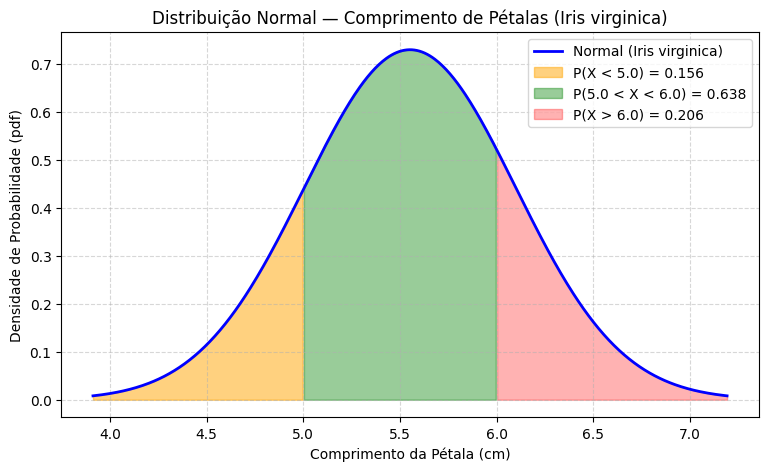

In [3]:
# Definindo os limites de interesse (em cm)
x1, x2 = 5.0, 6.0

# Probabilidades usando cdf (acumulada), diferença (entre valores) e sf (acima de)
p_acumulada = stats.norm.cdf(x1, loc=mu_v, scale=std_v)
p_entre = stats.norm.cdf(x2, loc=mu_v, scale=std_v) - stats.norm.cdf(
    x1, loc=mu_v, scale=std_v
)
p_acima = stats.norm.sf(x2, loc=mu_v, scale=std_v)  # sf(x) = 1 - cdf(x)

# Percentil 90
perc_90 = stats.norm.ppf(0.90, loc=mu_v, scale=std_v)

print(f'P(X < 5.0) = {p_acumulada:.4f}')
print(f'P(5.0 <= X <= 6.0) = {p_entre:.4f}')
print(f'P(X > 6.0) = {p_acima:.4f}')
print(f'Percentil 90 (P90) = {perc_90:.2f} cm')

# Gráfico com sombreamento
x = np.linspace(mu_v - 3 * std_v, mu_v + 3 * std_v, 500)
y = stats.norm.pdf(x, loc=mu_v, scale=std_v)

plt.figure(figsize=(9, 5))
plt.plot(x, y, 'b-', lw=2, label='Normal (Iris virginica)')
plt.fill_between(
    x,
    0,
    y,
    where=(x <= x1),
    color='orange',
    alpha=0.5,
    label=f'P(X < 5.0) = {p_acumulada:.3f}',
)
plt.fill_between(
    x,
    0,
    y,
    where=(x >= x1) & (x <= x2),
    color='green',
    alpha=0.4,
    label=f'P(5.0 < X < 6.0) = {p_entre:.3f}',
)
plt.fill_between(
    x,
    0,
    y,
    where=(x >= x2),
    color='red',
    alpha=0.3,
    label=f'P(X > 6.0) = {p_acima:.3f}',
)
plt.title('Distribuição Normal — Comprimento de Pétalas (Iris virginica)')
plt.xlabel('Comprimento da Pétala (cm)')
plt.ylabel('Densidade de Probabilidade (pdf)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Comparação Gráfica: A soma das áreas coloridas sob a curva (laranja + verde + vermelha) totaliza 1.0 (ou 100%), refletindo diretamente os valores numéricos calculados pelas funções acumuladas (cdf e sf). O percentil 90 (ppf) indica que 90% das flores da espécie possuem comprimento de pétala inferior a {perc_90:.2f} cm.

2. Distribuição t de Student: Estatística Padronizada da Média Amostral

Pergunta Contextualizada: Considerando uma amostra de tamanho $n = 50$ de *Iris virginica* ($\nu = 49$ graus de liberdade), qual é a probabilidade de que a estatística t padronizada da média amostral assuma valores menores que -1,96, valores entre -1,96 e +1,96, e valores superiores a +1,96?

Relação com o valor biológico: A estatística $t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$ padroniza a distância entre a média amostral observada ($\bar{x}$) e um valor de referência populacional ($\mu_0$), medida em unidades de erro padrão estimado.

P(t < -1.96) = 0.0278
P(-1.96 <= t <= 1.96) = 0.9443
P(t > 1.96) = 0.0278
Percentil 95 (t) = 1.68


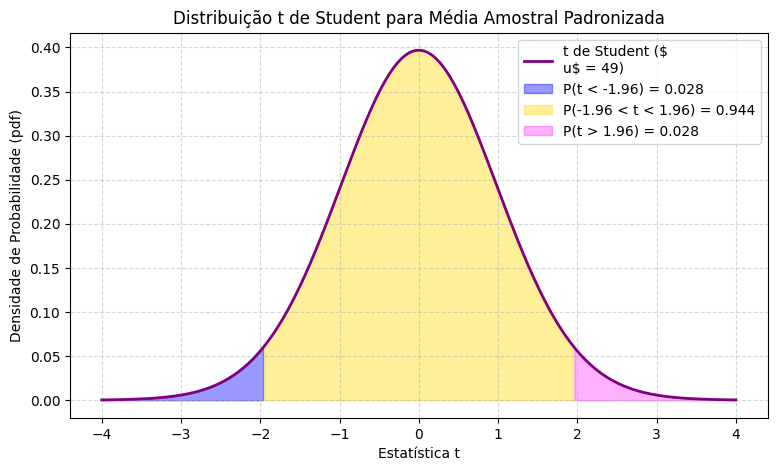

In [4]:
nu = n_vir - 1  # 49 graus de liberdade
t1, t2 = -1.96, 1.96

p_t_acum = stats.t.cdf(t1, df=nu)
p_t_entre = stats.t.cdf(t2, df=nu) - stats.t.cdf(t1, df=nu)
p_t_acima = stats.t.sf(t2, df=nu)
t_perc95 = stats.t.ppf(0.95, df=nu)

print(f'P(t < -1.96) = {p_t_acum:.4f}')
print(f'P(-1.96 <= t <= 1.96) = {p_t_entre:.4f}')
print(f'P(t > 1.96) = {p_t_acima:.4f}')
print(f'Percentil 95 (t) = {t_perc95:.2f}')

# Gráfico
t_vals = np.linspace(-4, 4, 500)
t_pdf = stats.t.pdf(t_vals, df=nu)

plt.figure(figsize=(9, 5))
plt.plot(
    t_vals,
    t_pdf,
    'purple',
    lw=2,
    label=f't de Student ($\nu$ = {nu})',
)
plt.fill_between(
    t_vals,
    0,
    t_pdf,
    where=(t_vals <= t1),
    color='blue',
    alpha=0.4,
    label=f'P(t < -1.96) = {p_t_acum:.3f}',
)
plt.fill_between(
    t_vals,
    0,
    t_pdf,
    where=(t_vals >= t1) & (t_vals <= t2),
    color='gold',
    alpha=0.4,
    label=f'P(-1.96 < t < 1.96) = {p_t_entre:.3f}',
)
plt.fill_between(
    t_vals,
    0,
    t_pdf,
    where=(t_vals >= t2),
    color='magenta',
    alpha=0.3,
    label=f'P(t > 1.96) = {p_t_acima:.3f}',
)
plt.title('Distribuição t de Student para Média Amostral Padronizada')
plt.xlabel('Estatística t')
plt.ylabel('Densidade de Probabilidade (pdf)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Comparação Gráfica: A área central amarela abrange aproximadamente 95% da distribuição t, ilustrando o intervalo de confiança clássico de 95% para testes de hipóteses bilaterais com 49 graus de liberdade.

3. Distribuição Qui-Quadrado ($\chi^2$): Inferência sobre a Variância Amostral

Pergunta Contextualizada: Dada a expressão amostral associada à variância de *Iris virginica* com $\nu = 49$ graus de liberdade ($\chi^2 = \frac{(n-1)s^2}{\sigma_0^2}$), qual é a probabilidade de que a estatística assuma valores abaixo de 35,0, valores entre 35,0 e 65,0, e valores acima de 65,0 sob a hipótese de uma variância populacional de referência $\sigma_0^2 = 0.25$?

Significado: Modela a flutuação amostral de quantidades proporcionais à variância baseadas na soma de quadrados normais.

P(chi2 < 35.0) = 0.0658
P(35.0 <= chi2 <= 65.0) = 0.8716
P(chi2 > 65.0) = 0.0626
Percentil 95 (chi2) = 66.34


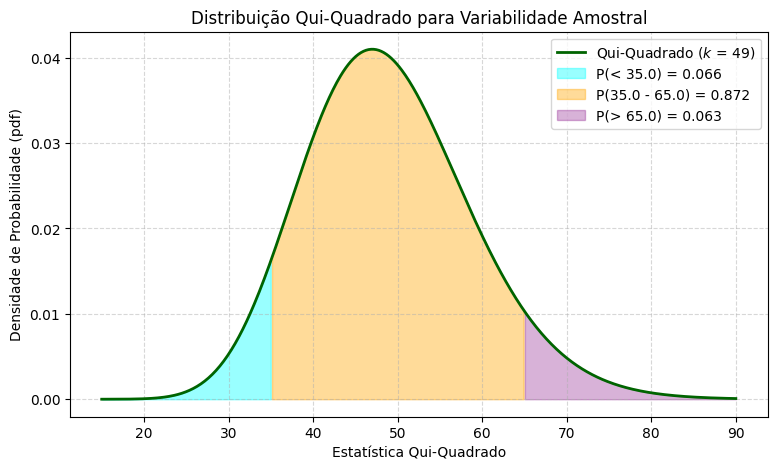

In [5]:
k = n_vir - 1
chi1, chi2 = 35.0, 65.0

p_chi_acum = stats.chi2.cdf(chi1, df=k)
p_chi_entre = stats.chi2.cdf(chi2, df=k) - stats.chi2.cdf(chi1, df=k)
p_chi_acima = stats.chi2.sf(chi2, df=k)
chi_perc95 = stats.chi2.ppf(0.95, df=k)

print(f'P(chi2 < 35.0) = {p_chi_acum:.4f}')
print(f'P(35.0 <= chi2 <= 65.0) = {p_chi_entre:.4f}')
print(f'P(chi2 > 65.0) = {p_chi_acima:.4f}')
print(f'Percentil 95 (chi2) = {chi_perc95:.2f}')

# Gráfico
chi_vals = np.linspace(15, 90, 500)
chi_pdf = stats.chi2.pdf(chi_vals, df=k)

plt.figure(figsize=(9, 5))
plt.plot(
    chi_vals,
    chi_pdf,
    'darkgreen',
    lw=2,
    label=f'Qui-Quadrado ($k$ = {k})',
)
plt.fill_between(
    chi_vals,
    0,
    chi_pdf,
    where=(chi_vals <= chi1),
    color='cyan',
    alpha=0.4,
    label=f'P(< 35.0) = {p_chi_acum:.3f}',
)
plt.fill_between(
    chi_vals,
    0,
    chi_pdf,
    where=(chi_vals >= chi1) & (chi_vals <= chi2),
    color='orange',
    alpha=0.4,
    label=f'P(35.0 - 65.0) = {p_chi_entre:.3f}',
)
plt.fill_between(
    chi_vals,
    0,
    chi_pdf,
    where=(chi_vals >= chi2),
    color='purple',
    alpha=0.3,
    label=f'P(> 65.0) = {p_chi_acima:.3f}',
)
plt.title('Distribuição Qui-Quadrado para Variabilidade Amostral')
plt.xlabel('Estatística Qui-Quadrado')
plt.ylabel('Densidade de Probabilidade (pdf)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Comparação Gráfica: A assimetria à direita da curva qui-quadrado fica evidente. O sombreado laranja encapsula a maior parte da área central de probabilidade entre os limites escolhidos.

4. Distribuição F de Fisher-Snedecor: Razão de Variâncias entre Espécies

Pergunta Contextualizada: Considerando a razão entre as variâncias amostrais do comprimento das pétalas de *Iris versicolor* ($s_1^2$) e *Iris virginica* ($s_2^2$), com $d_1 = 49$ e $d_2 = 49$ graus de liberdade, qual é a probabilidade de observar uma razão F inferior a 1,0, entre 1,0 e 1,8, e superior a 1,8 sob as condições do modelo nulo de igualdade de variâncias?

Interpretação Crítica: Lembre-se de que a área sob a curva F não é a probabilidade direta de que uma espécie tenha “mais variabilidade” que outra; ela modela estritamente o comportamento probabilístico de uma razão de variâncias amostrais sob a hipótese de que as variâncias populacionais reais são iguais.

P(F < 1.0) = 0.5000
P(1.0 <= F <= 1.8) = 0.4789
P(F > 1.8) = 0.0211
Percentil 95 (F) = 1.61


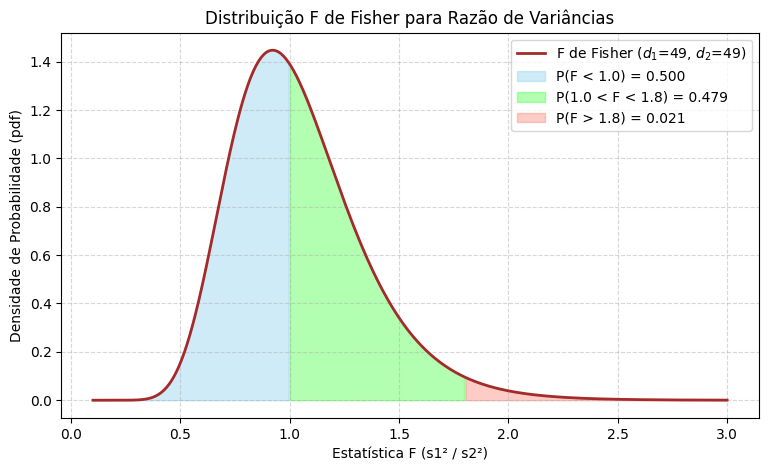

In [7]:
d1 = len(petala_versicolor) - 1
d2 = len(petala_virginica) - 1
f1, f2 = 1.0, 1.8

p_f_acum = stats.f.cdf(f1, dfn=d1, dfd=d2)
p_f_entre = stats.f.cdf(f2, dfn=d1, dfd=d2) - stats.f.cdf(f1, dfn=d1, dfd=d2)
p_f_acima = stats.f.sf(f2, dfn=d1, dfd=d2)
f_perc95 = stats.f.ppf(0.95, dfn=d1, dfd=d2)

print(f'P(F < 1.0) = {p_f_acum:.4f}')
print(f'P(1.0 <= F <= 1.8) = {p_f_entre:.4f}')
print(f'P(F > 1.8) = {p_f_acima:.4f}')
print(f'Percentil 95 (F) = {f_perc95:.2f}')

# Gráfico
f_vals = np.linspace(0.1, 3.0, 500)
f_pdf = stats.f.pdf(f_vals, dfn=d1, dfd=d2)

plt.figure(figsize=(9, 5))
plt.plot(
    f_vals,
    f_pdf,
    'brown',
    lw=2,
    label=f'F de Fisher ($d_1$={d1}, $d_2$={d2})',
)
plt.fill_between(
    f_vals,
    0,
    f_pdf,
    where=(f_vals <= f1),
    color='skyblue',
    alpha=0.4,
    label=f'P(F < 1.0) = {p_f_acum:.3f}',
)
plt.fill_between(
    f_vals,
    0,
    f_pdf,
    where=(f_vals >= f1) & (f_vals <= f2),
    color='lime',
    alpha=0.3,
    label=f'P(1.0 < F < 1.8) = {p_f_entre:.3f}',
)
plt.fill_between(
    f_vals,
    0,
    f_pdf,
    where=(f_vals >= f2),
    color='salmon',
    alpha=0.4,
    label=f'P(F > 1.8) = {p_f_acima:.3f}',
)
plt.title('Distribuição F de Fisher para Razão de Variâncias')
plt.xlabel('Estatística F (s1² / s2²)')
plt.ylabel('Densidade de Probabilidade (pdf)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Comparação Gráfica e Conclusão: O gráfico exibe claramente a assimetria característica da distribuição F. O valor crítico do percentil 95 (f_perc95) delimita a região de rejeição para um teste estatístico bilateral/unilateral padrão ao nível de significância de 5%, permitindo concluir rigorosamente se a diferença observada nas variâncias das pétalas entre as duas espécies de *Iris* é ou não estatisticamente defensável sob o modelo proposto.